In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

#install.packages("tibble")
#install.packages("dplyr")
#install.packages(ggplot2)
#install.packages("caret")
#install.packages("glmnet")

library(tibble)
library(dplyr)
library(ggplot2)
library(caret)
library(pROC)
library(ROSE)
library(glmnet)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: lattice
Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var

Loaded ROSE 0.0-4

Loading required package: Matrix
Loaded glmnet 4.1-8
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [3]:
%%R

binary_driving_mode <- function (df_chassis) {
    result <- ifelse(df_chassis$drivingMode == "COMPLETE_AUTO_DRIVE", 1, 0)

    return(result)
}


merge_chassis_pose <- function (df_chassis, df_pose) {
    
    
    df_chassis <- df_chassis[order(df_chassis$time), ]
    df_pose <- df_pose[order(df_pose$time), ]
    
    #make sure data is sorted by time fist

    chassis_time_arr <- df_chassis$time
    pose_time_arr <- df_pose$time

    matched_vector <- c()

    for (chassis_time in chassis_time_arr) {
        abs_time_diff_arr <- abs(pose_time_arr - chassis_time)

        min_index <-  which(abs_time_diff_arr == min(abs_time_diff_arr))
        
        matched_vector <-  c(matched_vector, pose_time_arr[min_index])
    }



    #df_chassis$matched <- df_pose$time[which(abs(pose_time_arr - df_chassis$time) == min(abs(pose_time_arr - df_chassis$time)))]
    df_chassis$matched <-  matched_vector
    df_pose$matched <-  df_pose$time


    return (list(df_chassis = df_chassis, df_pose = df_pose))


}

latlongStdDev <- function(df_pose){
    x <- df_pose["latitudeStdDev"]
    y <- df_pose["longitudeStdDev"]
    r <- sqrt(x^2 + y^2)

    return(r)

}

In [4]:
%%R
# Defining GMIDs for Red Routes
# Am creating a list of GMIDs for processing
red_route_gmIDs  <- c(
     '61b12e7a-f234-11ee-bb33-fb353e7798cd',
'fcc6fcd2-f013-11ee-b966-fb353e7798cd',
'05c7c824-cab8-11ee-aa4d-1d66adf2f0c7',
'211bdb36-f0da-11ee-ba1b-fb353e7798cd',
'868de15e-f3b3-11ee-bb4e-fb353e7798cd',
'72a03d4a-efe9-11ee-b966-fb353e7798cd',
'7fb7b9c0-c881-11ee-a7fc-dd032dba19e8',
'96f7a614-f549-11ee-8afa-cb629b0d53e6',
'1bbbfbae-c839-11ee-a7fc-dd032dba19e8',
'622bd2e8-f0e4-11ee-ba1f-fb353e7798cd',
'9798fe24-f143-11ee-ba78-fb353e7798cd',
'88dd6fbe-f224-11ee-bb21-fb353e7798cd',
'c9c6856c-d33c-11ee-b437-336917683bb8',
'd12cd1c4-caec-11ee-909c-e1dc60cf66f9',
'817d6848-efb6-11ee-b966-fb353e7798cd',
'1b6aca0e-efdf-11ee-b966-fb353e7798cd',
'41b67a28-f52f-11ee-8afa-cb629b0d53e6',
'fc211bb2-efca-11ee-b966-fb353e7798cd',
'84d96f18-f214-11ee-bb13-fb353e7798cd',
'fe973c9c-f53c-11ee-8afa-cb629b0d53e6',
'3151e9e2-eff3-11ee-b966-fb353e7798cd',
'c0555ef0-f50f-11ee-8afa-cb629b0d53e6',
'f711e68e-f0e1-11ee-ba1f-fb353e7798cd',
'c338788a-d324-11ee-b437-336917683bb8',
'd21965e6-f0fa-11ee-ba37-fb353e7798cd',
'88a68dd8-eef9-11ee-9385-ef789ffde1d3',
'f41cbd44-eff8-11ee-b966-fb353e7798cd',
'43a1a35e-f362-11ee-bb4e-fb353e7798cd',
'6d2ea45a-c839-11ee-a7fc-dd032dba19e8',
'01e65360-efd4-11ee-b966-fb353e7798cd',
'7cbd932e-f244-11ee-bb3f-fb353e7798cd',
'65cfbfd6-f396-11ee-bb4e-fb353e7798cd',
'94c53148-eeed-11ee-9385-ef789ffde1d3',
'fd1ab258-efa7-11ee-b966-fb353e7798cd',
'e7b934a8-ef1a-11ee-9385-ef789ffde1d3',
'de933de8-f112-11ee-ba4d-fb353e7798cd',
'd3698592-ef9d-11ee-b966-fb353e7798cd',
'dd72fdec-f0cf-11ee-ba0d-fb353e7798cd',
'b82476fe-f1f3-11ee-baff-fb353e7798cd',
'f755cf60-f132-11ee-ba6d-fb353e7798cd',
'853ef120-cad3-11ee-909c-e1dc60cf66f9',
'f0eebb6a-f0dc-11ee-ba1e-fb353e7798cd',
'cf831f42-f353-11ee-bb4e-fb353e7798cd',
'ecebb942-f162-11ee-ba97-fb353e7798cd',
'219f7eb8-ef87-11ee-b966-fb353e7798cd',
'd24820c8-f197-11ee-babe-fb353e7798cd',
'3d2d29ec-ef95-11ee-b966-fb353e7798cd',
'457dc5ee-f02a-11ee-b966-fb353e7798cd',
'2462c9d0-eecd-11ee-9385-ef789ffde1d3',
'51ef6da6-ca9f-11ee-909c-e1dc60cf66f9',
'c25271be-f3a4-11ee-bb4e-fb353e7798cd',
'8347b862-efad-11ee-b966-fb353e7798cd',
'8dbbbf1c-f0ef-11ee-ba29-fb353e7798cd',
'9189a2a8-f121-11ee-ba5b-fb353e7798cd',
'8fa6fe80-c869-11ee-a7fc-dd032dba19e8',
'5a4bccf4-effe-11ee-b966-fb353e7798cd'
)

In [5]:
%%R

df_merged <- tibble() # Ensure it's an empty tibble

for (id in red_route_gmIDs) {
    print(paste("Processing GMID:", id))
    
    temp_chassis_path <- sprintf("/home/gampadu_linux/Desktop/TDMprivate/data/%s/_apollo_canbus_chassis/%s_apollo_canbus_chassis.csv", id, id)
    temp_pose_path <- sprintf("/home/gampadu_linux/Desktop/TDMprivate/data/%s/_apollo_sensor_gnss_best_pose/%s_apollo_sensor_gnss_best_pose.csv", id, id)

    if (file.exists(temp_chassis_path) && file.exists(temp_pose_path)) {
        temp_chassis <- as_tibble(read.csv(temp_chassis_path))
        temp_pose <- as_tibble(read.csv(temp_pose_path))

        r <- latlongStdDev(temp_pose)
        temp_pose$latlongStdDev <- r

        results <- merge_chassis_pose(temp_chassis, temp_pose)
        result_full <- full_join(results$df_chassis, results$df_pose, by = "matched")

        result_full$binaryDrivingMode <- binary_driving_mode(result_full)
        df_merged <- bind_rows(df_merged, result_full)
    } else {
        warning(sprintf("Files not found for GMID: %s", id))
    }
}
print("Done loading data")

[1] "Processing GMID: 61b12e7a-f234-11ee-bb33-fb353e7798cd"
[1] "Processing GMID: fcc6fcd2-f013-11ee-b966-fb353e7798cd"
[1] "Processing GMID: 05c7c824-cab8-11ee-aa4d-1d66adf2f0c7"
[1] "Processing GMID: 211bdb36-f0da-11ee-ba1b-fb353e7798cd"
[1] "Processing GMID: 868de15e-f3b3-11ee-bb4e-fb353e7798cd"
[1] "Processing GMID: 72a03d4a-efe9-11ee-b966-fb353e7798cd"
[1] "Processing GMID: 7fb7b9c0-c881-11ee-a7fc-dd032dba19e8"
[1] "Processing GMID: 96f7a614-f549-11ee-8afa-cb629b0d53e6"
[1] "Processing GMID: 1bbbfbae-c839-11ee-a7fc-dd032dba19e8"
[1] "Processing GMID: 622bd2e8-f0e4-11ee-ba1f-fb353e7798cd"
[1] "Processing GMID: 9798fe24-f143-11ee-ba78-fb353e7798cd"
[1] "Processing GMID: 88dd6fbe-f224-11ee-bb21-fb353e7798cd"
[1] "Processing GMID: c9c6856c-d33c-11ee-b437-336917683bb8"
[1] "Processing GMID: d12cd1c4-caec-11ee-909c-e1dc60cf66f9"
[1] "Processing GMID: 817d6848-efb6-11ee-b966-fb353e7798cd"
[1] "Processing GMID: 1b6aca0e-efdf-11ee-b966-fb353e7798cd"
[1] "Processing GMID: 41b67a28-f52f-11ee

In [6]:
%%R
training_gmIDs <- red_route_gmIDs[red_route_gmIDs != "5a4bccf4-effe-11ee-b966-fb353e7798cd"]
testing_gmIDs <- "5a4bccf4-effe-11ee-b966-fb353e7798cd"

train_data <- df_merged %>% filter(groupMetadataID.x %in% training_gmIDs)
test_data <- df_merged %>% filter(groupMetadataID.x == testing_gmIDs)

print(paste("Training Data Rows:", nrow(train_data)))
print(paste("Testing Data Rows:", nrow(test_data)))

if (nrow(test_data) == 0) {
    stop("Error: Test data is empty. Check GMID filtering.")
}

[1] "Training Data Rows: 3001134"
[1] "Testing Data Rows: 54579"


In [9]:
%%R
# Train a Logistic Regression Model
model <- glm(
  binaryDrivingMode ~ speedMps + throttlePercentage + brakePercentage + steeringPercentage + latlongStdDev,
  data = train_data,
  family = binomial
)

summary(model)

Error in model.frame.default(formula = binaryDrivingMode ~ speedMps +  : 
  invalid type (list) for variable 'latlongStdDev'


RInterpreterError: Failed to parse and evaluate line '# Train a Logistic Regression Model\nmodel <- glm(\n  binaryDrivingMode ~ speedMps + throttlePercentage + brakePercentage + steeringPercentage + latlongStdDev,\n  data = train_data,\n  family = binomial\n)\n\nsummary(model)\n'.
R error message: "Error in model.frame.default(formula = binaryDrivingMode ~ speedMps +  : \n  invalid type (list) for variable 'latlongStdDev'"

In [55]:
%%R
test_data$latlongStdDev <- as.numeric(unlist(test_data$latlongStdDev))

In [56]:
%%R
predictions <- predict(model, test_data, type = "response")
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

accuracy <- mean(predicted_classes == test_data$binaryDrivingMode)
print(paste("Accuracy:", accuracy))

Error in predict(model, test_data, type = "response") : 
  object 'model' not found


RInterpreterError: Failed to parse and evaluate line 'predictions <- predict(model, test_data, type = "response")\npredicted_classes <- ifelse(predictions > 0.5, 1, 0)\n\naccuracy <- mean(predicted_classes == test_data$binaryDrivingMode)\nprint(paste("Accuracy:", accuracy))\n'.
R error message: 'Error in predict(model, test_data, type = "response") : \n  object \'model\' not found'

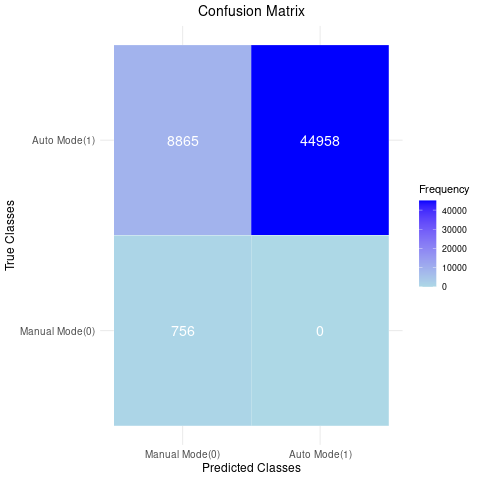

In [29]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Map the values to labels (1 -> "Auto_mode", 0 -> "Manual")
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Manual Mode(0)", "Auto Mode(1)"))
actual_classes_labeled <- factor (test_data$binaryDrivingMode, levels = c(0,1), labels = c("Manual Mode(0)", "Auto Mode(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)

# Rename columns for better understanding
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 14),
        axis.title = element_text(size = 12),
        axis.text = element_text(size = 10))

In [18]:
%%R

actual_manual_mode <- test_data[test_data$binaryDrivingMode == 0, ]
actual_latitudes <- actual_manual_mode$latitude
actual_longitudes <- actual_manual_mode$longitude

predicted_manual_mode <- test_data[predicted_classes == 0, ]
predicted_latitudes <- predicted_manual_mode$latitude
predicted_longitudes <- predicted_manual_mode$longitude

min_length <- min(length(actual_latitudes), length(predicted_latitudes))
actual_latitudes <- actual_latitudes[1:min_length]
actual_longitudes <- actual_longitudes[1:min_length]
predicted_latitudes <- predicted_latitudes[1:min_length]
predicted_longitudes <- predicted_longitudes[1:min_length]

manual_mode_comparison <- data.frame(
    actual_latitude = actual_latitudes,
    actual_longitude = actual_longitudes,
    predicted_latitude = predicted_latitudes,
    predicted_longitude = predicted_longitudes
)

print(head(manual_mode_comparison))

Error in `[.tbl_df`(test_data, predicted_classes == 0, ) : 
  object 'predicted_classes' not found


RInterpreterError: Failed to parse and evaluate line '\nactual_manual_mode <- test_data[test_data$binaryDrivingMode == 0, ]\nactual_latitudes <- actual_manual_mode$latitude\nactual_longitudes <- actual_manual_mode$longitude\n\npredicted_manual_mode <- test_data[predicted_classes == 0, ]\npredicted_latitudes <- predicted_manual_mode$latitude\npredicted_longitudes <- predicted_manual_mode$longitude\n\nmin_length <- min(length(actual_latitudes), length(predicted_latitudes))\nactual_latitudes <- actual_latitudes[1:min_length]\nactual_longitudes <- actual_longitudes[1:min_length]\npredicted_latitudes <- predicted_latitudes[1:min_length]\npredicted_longitudes <- predicted_longitudes[1:min_length]\n\nmanual_mode_comparison <- data.frame(\n    actual_latitude = actual_latitudes,\n    actual_longitude = actual_longitudes,\n    predicted_latitude = predicted_latitudes,\n    predicted_longitude = predicted_longitudes\n)\n\nprint(head(manual_mode_comparison))\n'.
R error message: "Error in `[.tbl_

In [17]:
import rpy2.robjects as robjects
import pandas as pd
from rpy2.robjects import pandas2ri
from rpy2.robjects import conversion

# Activate automatic pandas conversion
pandas2ri.activate()

# Fetch the R dataframe
manual_mode_comparison_r = robjects.globalenv["manual_mode_comparison"]

# Convert R DataFrame to Pandas
manual_mode_comparison_py = conversion.rpy2py(manual_mode_comparison_r)

# Rename for clarity
df = manual_mode_comparison_py

# Display first few rows
print(df.head())

KeyError: "'manual_mode_comparison' not found"

TypeError: Indices must be integers or slices, not <class 'str'>

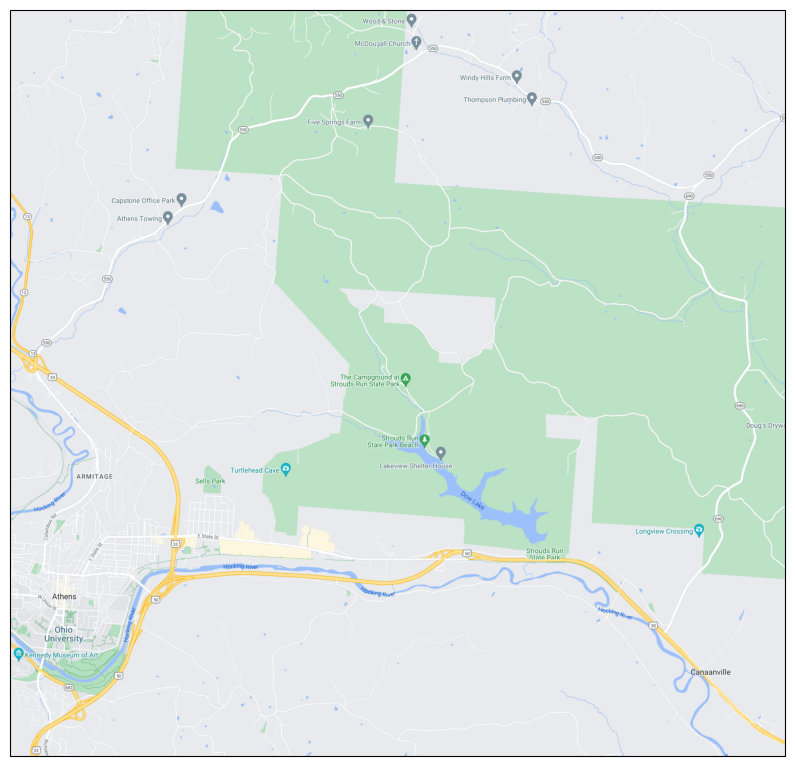

In [38]:
import cartopy.crs as ccrs
from cartopy.io.img_tiles import GoogleTiles
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

#minLat, maxLat = df['actual_latitude'].min(), df['actual_latitude'].max()
#minLon, maxLon = df['actual_longitude'].min(), df['actual_longitude'].max()
minLat= 39.3124906671225
maxLat= 39.40448581121833
minLon= -82.10582075491102
maxLon= -81.9788697421841

expansion_coeff = 0.005

street_map = GoogleTiles(style='street')

ax = plt.axes(projection=street_map.crs)
ax.set_extent(
    [minLon - expansion_coeff, maxLon + expansion_coeff, 
     minLat - expansion_coeff, maxLat + expansion_coeff], 
    ccrs.PlateCarree()
)

ax.add_image(street_map, 14)

true_manual_lat = df['actual_latitude']
true_manual_lon = df['actual_longitude']
pred_manual_lat = df['predicted_latitude']
pred_manual_lon = df['predicted_longitude']

plt.plot(true_manual_lon, true_manual_lat, 
         marker='o', ls='', color='blue', ms=5, 
         label='Actual Manual Mode', transform=ccrs.PlateCarree())

plt.plot(pred_manual_lon, pred_manual_lat, 
         marker='o', ls='', color='red', ms=5, 
         label='Predicted Manual Mode', transform=ccrs.PlateCarree())

plt.title('Actual vs Predicted Manual Mode Locations')
plt.legend()
plt.show()

In [28]:
print(df_test_gmid.head())  # Verify if latitude and longitude are present
print(df_test_gmid[['latitude', 'longitude']].describe())  # Check min/max values

NameError: name 'df_test_gmid' is not defined

TypeError: Indices must be integers or slices, not <class 'str'>

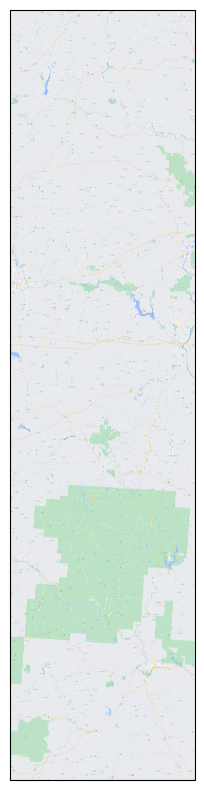

In [27]:
# Replace these values with the actual ones you got from R
minLat, maxLat = 39.1234, 40.5678  # Replace with R values
minLon, maxLon = -82.4321, -81.9876  # Replace with R values

# Define plot size
plt.figure(figsize=(10, 10))

# Define expansion coefficient to avoid edge cutoff
expansion_coeff = 0.005

# Load street map
street_map = GoogleTiles(style='street')

# Create plot with the street map
ax = plt.axes(projection=street_map.crs)
ax.set_extent(
    [minLon - expansion_coeff, maxLon + expansion_coeff, 
     minLat - expansion_coeff, maxLat + expansion_coeff],
    ccrs.PlateCarree()
)

# Add map image
ax.add_image(street_map, 14)

# Extract actual and predicted manual mode locations
true_manual_lat = df['actual_latitude']
true_manual_lon = df['actual_longitude']

pred_manual_lat = df['predicted_latitude']
pred_manual_lon = df['predicted_longitude']

# Plot actual manual mode points (Blue)
plt.plot(true_manual_lon, true_manual_lat, 
         marker='o', ls='', color='blue', ms=5, 
         label='Actual Manual Mode', transform=ccrs.PlateCarree())

# Plot predicted manual mode points (Red)
plt.plot(pred_manual_lon, pred_manual_lat, 
         marker='o', ls='', color='red', ms=5, 
         label='Predicted Manual Mode', transform=ccrs.PlateCarree())

# Add title and legend
plt.title('Actual vs Predicted Manual Mode Locations')
plt.legend()

# Show the plot
plt.show()